- # Installation

In [1]:
pip install -q baccoemu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 7.2 MB/s eta 0:00:00


- # Import Libraries and Load Emulator

In [7]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import baccoemu
warnings.filterwarnings('ignore')

# Load the matter power spectrum emulator
emulator = baccoemu.Matter_powerspectrum(verbose=False)

# Get emulator information for nonlinear case
print("Nonlinear emulator k-range:")
print(emulator.emulator['nonlinear']['k'])

print("\nNonlinear emulator parameters and bounds:")
for key, bound in zip(emulator.emulator['nonlinear']['keys'], emulator.emulator['nonlinear']['bounds']):
    print(key, bound)


Nonlinear emulator k-range:
[0.01019735 0.01060381 0.01102647 0.01146598 0.01192301 0.01239826
 0.01289244 0.01340633 0.0139407  0.01449637 0.01507419 0.01567503
 0.01629983 0.01694954 0.01762514 0.01832766 0.0190582  0.01981784
 0.02060777 0.02142919 0.02228335 0.02317155 0.02409515 0.02505557
 0.02605428 0.02709279 0.02817269 0.02929564 0.03046335 0.0316776
 0.03294025 0.03425323 0.03561855 0.03703829 0.03851461 0.04004979
 0.04164615 0.04330614 0.0450323  0.04682727 0.04869378 0.05063469
 0.05265296 0.05475168 0.05693405 0.05920341 0.06156323 0.06401711
 0.0665688  0.0692222  0.07198136 0.0748505  0.077834   0.08093642
 0.0841625  0.08751718 0.09100557 0.094633   0.09840502 0.1023274
 0.10640611 0.1106474  0.11505775 0.11964389 0.12441284 0.12937187
 0.13452856 0.1398908  0.14546677 0.151265   0.15729435 0.16356402
 0.1700836  0.17686304 0.18391271 0.19124337 0.19886623 0.20679294
 0.2150356  0.2236068  0.23251965 0.24178776 0.2514253  0.26144698
 0.27186812 0.28270464 0.2939731  0.

- # Define Wavemodes Vector and Cosmological Parameters

In [3]:
# Define wavemodes vector using the maximum k from nonlinear emulator
k = np.logspace(-2, np.log10(emulator.emulator['nonlinear']['k'].max()), num=100)

# Define cosmological parameters
params = {
    'omega_cold'    :  0.315,
    'sigma8_cold'   :  0.83,  # if A_s is not specified
    'omega_baryon'  :  0.05,
    'ns'            :  0.96,
    'hubble'        :  0.67,
    'neutrino_mass' :  0.0,
    'w0'            : -1.0,
    'wa'            :  0.0,
    'expfactor'     :  1
}

- # Evaluate Power Spectra and Nonlinear Boost

In [4]:
# Evaluate nonlinear boost (Q factor) for total matter only
k, Q_total = emulator.get_nonlinear_boost(k=k, cold=False, **params)

# Evaluate linear power spectrum (needed for comparison) for total matter only
k, pk_lin_total = emulator.get_linear_pk(k=k, cold=False, **params)

# Evaluate nonlinear power spectrum for total matter only
k, pk_nl_total = emulator.get_nonlinear_pk(k=k, cold=False, **params)

- # Plot Results

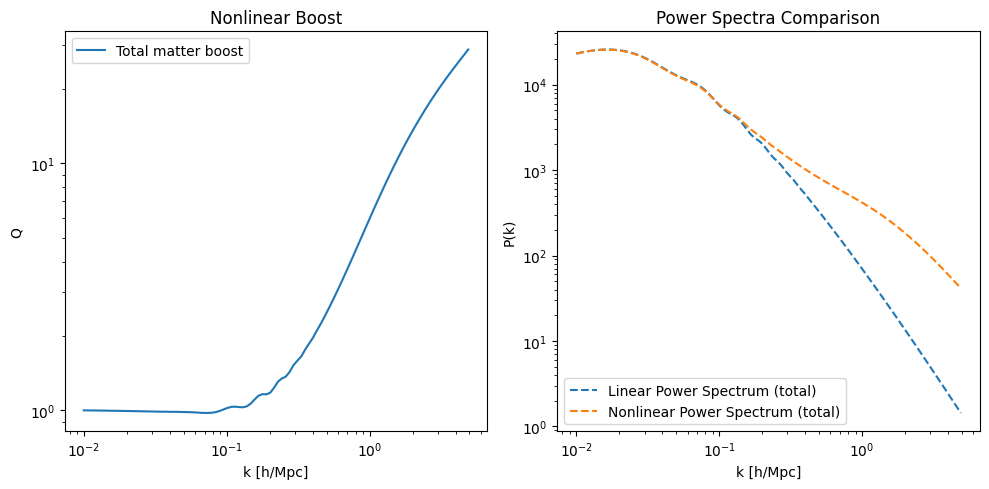

In [5]:
# Plot the results
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Plot nonlinear boost for total matter
ax[0].loglog(k, Q_total, label='Total matter boost')
ax[0].set_xlabel("k [h/Mpc]")
ax[0].set_ylabel("Q")
ax[0].set_title("Nonlinear Boost")
ax[0].legend()

# Plot power spectra comparison for total matter only
ax[1].loglog(k, pk_lin_total, '--', label="Linear Power Spectrum (total)")
ax[1].loglog(k, pk_nl_total, '--', label="Nonlinear Power Spectrum (total)")
ax[1].set_xlabel("k [h/Mpc]")
ax[1].set_ylabel("P(k)")
ax[1].set_title("Power Spectra Comparison")
ax[1].legend()

plt.tight_layout()
plt.show()

- # Print Summary

In [6]:
# Print some information about the results
print(f"\nResults summary:")
print(f"k-range: {k.min():.3f} to {k.max():.3f} h/Mpc")
print(f"Number of k modes: {len(k)}")
print(f"Total matter nonlinear boost at k=1 h/Mpc: {Q_total[np.argmin(np.abs(k-1.0))]:.3f}")
print(f"Total matter P(k) enhancement at k=1 h/Mpc: {(pk_nl_total[np.argmin(np.abs(k-1.0))]/pk_lin_total[np.argmin(np.abs(k-1.0))]):.3f}")


Results summary:
k-range: 0.010 to 4.903 h/Mpc
Number of k modes: 100
Total matter nonlinear boost at k=1 h/Mpc: 6.160
Total matter P(k) enhancement at k=1 h/Mpc: 6.160
